# S01. Train-test split sensitivity

This notebook runs train-test split sensitivity tests for four AIMS4PT_cpx tasks. The sensitivity splits use the same pressure-binned `StratifiedShuffleSplit(test_size=0.2, random_state=42)` setup as `00_independent_dataset.ipynb`, with `n_splits=10` for repeated random 80/20 train-test splits.

Original manuscript RMSE values are entered manually as reference points for plotting and summaries. They are not recomputed and are not included in split statistics.

Outputs are written to `paper/.cache/S01_train_test_split_sensitivity/`.


In [1]:
from pathlib import Path
import sys


def find_project_root(start=None):
    """Find the project root by walking upward."""
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml above the current directory.")


PROJECT_ROOT = find_project_root()
PAPER_DIR = PROJECT_ROOT / "paper"
CACHE_DIR = PAPER_DIR / ".cache" / "S01_train_test_split_sensitivity"
for subdir in ["config", "splits", "models", "predictions", "metrics", "figures"]:
    (CACHE_DIR / subdir).mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import json
import os
import shutil
import pickle
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

from aims4pt.model_tools.model_registry import get_models_initial_pools, ALL_MODELS_MODULES
from aims4pt.model_tools.deviation_models import deviation_model_for_a_thermobarometer
from aims4pt.model_tools.CpxTBSelect import workflow_thermobarometry
from aims4pt.toolkit_utils import load_pickle_compat

for module in ALL_MODELS_MODULES:
    importlib.import_module(module)

CACHE_DIR


WindowsPath('c:/Users/13493/Documents/PROJECTS/Cpx_thermobarometry_recommend_202507/code/AIMS4PT/paper/.cache/S01_train_test_split_sensitivity')

`TASKS_TO_RUN` runs the four split-sensitivity tasks in one pass. Pressure tasks report overall `rmse` and `rmse (0-10kbar)`; temperature tasks report only overall `rmse`. The ten sensitivity splits retrain only the deviation functions. The `original model` reference is entered manually and is plotted separately from the split statistics.


In [2]:
TASKS_TO_RUN = ["P_cpx_only", "P_cpx_liq", "T_cpx_only", "T_cpx_liq"]
ORIGINAL_WORKFLOW_DEVIATION_N_ITER = 100
NUM_SENSITIVITY_SPLITS = 10
BASE_RANDOM_STATE = 42
LOW_PRESSURE_RMSE_COL = "rmse (0-10kbar)"
DATA_DIR = PAPER_DIR / "data"

INPUT_DATASET = os.path.join(DATA_DIR, "independent_data_raw.xlsx")

TASK_SPECS = {
    "P_cpx_only": dict(target_kind="P", target_col="P (kbar)", cpx_only=True),
    "P_cpx_liq": dict(target_kind="P", target_col="P (kbar)", cpx_only=False),
    "T_cpx_only": dict(target_kind="T", target_col="T (C)", cpx_only=True),
    "T_cpx_liq": dict(target_kind="T", target_col="T (C)", cpx_only=False),
}
TASK_SPECS = {task_name: TASK_SPECS[task_name] for task_name in TASKS_TO_RUN}
TASK_DISPLAY_NAMES = {
    "P_cpx_only": "P cpx-only",
    "P_cpx_liq": "P cpx-liq",
    "T_cpx_only": "T cpx-only",
    "T_cpx_liq": "T cpx-liq",
}
ORIGINAL_REFERENCE_VALUES = {
    "P_cpx_only": {"rmse": 2.68, LOW_PRESSURE_RMSE_COL: 1.53},
    "P_cpx_liq": {"rmse": 2.46, LOW_PRESSURE_RMSE_COL: 1.68},
    "T_cpx_only": {"rmse": 58.0},
    "T_cpx_liq": {"rmse": 41.0},
}

with open(CACHE_DIR / "config" / "run_config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "tasks": TASKS_TO_RUN,
            "deviation_n_iter": ORIGINAL_WORKFLOW_DEVIATION_N_ITER,
            "num_sensitivity_splits": NUM_SENSITIVITY_SPLITS,
            "base_random_state": BASE_RANDOM_STATE,
            "low_pressure_metric": LOW_PRESSURE_RMSE_COL,
            "input_dataset": str(INPUT_DATASET),
            "original_reference_values": ORIGINAL_REFERENCE_VALUES,
            "cache_dir": str(CACHE_DIR),
        },
        f,
        indent=2,
        ensure_ascii=False,
    )


## Load and clean the independent dataset

This follows the same cleaning sequence as `00_independent_dataset.ipynb`: clinopyroxene oxide-total filtering, clinopyroxene stoichiometry filtering, and Fe-Mg Kd equilibrium filtering.

In [3]:
unseen_experiments_df = pd.read_excel(INPUT_DATASET)

cpx_names = [
    "SiO2_cpx", "TiO2_cpx", "Al2O3_cpx", "Fe2O3_cpx", "Cr2O3_cpx",
    "FeO_cpx", "MnO_cpx", "MgO_cpx", "NiO_cpx", "CoO_cpx", "CaO_cpx",
    "Na2O_cpx", "K2O_cpx", "P2O5_cpx",
]
liq_names = [
    "SiO2_liq", "TiO2_liq", "Al2O3_liq", "Fe2O3_liq", "Cr2O3_liq",
    "FeO_liq", "MnO_liq", "MgO_liq", "NiO_liq", "CoO_liq", "CaO_liq",
    "Na2O_liq", "K2O_liq", "P2O5_liq",
]
P_col = "P (kbar)"
T_col = "T (C)"

if "sample_id" not in unseen_experiments_df.columns:
    unseen_experiments_df.insert(0, "sample_id", "row_" + unseen_experiments_df.index.astype(str))
unseen_experiments_df["sample_id"] = unseen_experiments_df["sample_id"].astype(str)

print("Before cleaning:", unseen_experiments_df.shape)
cpx_total = unseen_experiments_df[cpx_names].sum(axis=1)
unseen_experiments_df = unseen_experiments_df[(cpx_total > 98) & (cpx_total < 102)].reset_index(drop=True)
print("After cpx total:", unseen_experiments_df.shape)

from aims4pt.data_tools.compositions import cpx_calculation
cpx_params = cpx_calculation(unseen_experiments_df[cpx_names])
MdivT = cpx_params["(Ca+Fe+Mg)/Si"]
unseen_experiments_df = unseen_experiments_df[(MdivT > 0.9) & (MdivT < 1.1)].reset_index(drop=True)
print("After cpx MdivT:", unseen_experiments_df.shape)

from aims4pt.data_tools.equilibrium import kdEquilibrium_test
mask, kd_values = kdEquilibrium_test(
    unseen_experiments_df[cpx_names],
    unseen_experiments_df[liq_names],
    kd=0.28,
    error=0.08,
    mode="Fe-Mg",
)
unseen_experiments_df = unseen_experiments_df[mask].reset_index(drop=True)
print("After kd filter:", unseen_experiments_df.shape)

cpx_unseen = unseen_experiments_df[cpx_names].copy()
liq_unseen = unseen_experiments_df[liq_names].copy()
meta_unseen = unseen_experiments_df[["sample_id", P_col, T_col]].copy()

Before cleaning: (517, 37)
After cpx total: (497, 37)
After cpx MdivT: (441, 37)
After kd filter: (293, 37)


## Five split definitions

Fold 0 is the original manuscript train-test split. Folds 1-4 are additional held-out folds generated from the original training subset.

In [4]:
P_values = unseen_experiments_df[P_col]
target_bin_size = 50
num_bins = max(2, min(10, len(P_values) // target_bin_size))
P_binned = pd.qcut(P_values, q=num_bins, labels=False, duplicates="drop")

# Repeated manuscript-style random 80/20 pressure-stratified splits.
sss = StratifiedShuffleSplit(
    n_splits=NUM_SENSITIVITY_SPLITS,
    test_size=0.2,
    random_state=BASE_RANDOM_STATE,
)
folds = []
for fold_id, (strat_train_idx, strat_test_idx) in enumerate(sss.split(unseen_experiments_df, P_binned), start=1):
    folds.append(
        dict(
            split_id=f"split_{fold_id:04d}",
            fold_id=fold_id,
            train_idx=np.array(strat_train_idx),
            test_idx=np.array(strat_test_idx),
            is_original_split=False,
        )
    )

split_rows = []
for fold in folds:
    split_rows.append({
        "split_id": fold["split_id"],
        "fold_id": fold["fold_id"],
        "is_original_split": fold["is_original_split"],
        "n_train": len(fold["train_idx"]),
        "n_test": len(fold["test_idx"]),
    })
split_manifest = pd.DataFrame(split_rows)
split_manifest.to_csv(CACHE_DIR / "splits" / "split_manifest.csv", index=False)
split_manifest


,split_id,fold_id,is_original_split,n_train,n_test
0,split_0001,1,False,234,59
1,split_0002,2,False,234,59
2,split_0003,3,False,234,59
3,split_0004,4,False,234,59
4,split_0005,5,False,234,59
5,split_0006,6,False,234,59
6,split_0007,7,False,234,59
7,split_0008,8,False,234,59
8,split_0009,9,False,234,59
9,split_0010,10,False,234,59


## Model pool and fixed OOD detectors

Existing OOD detectors are loaded from trained AIMS4PT resources. They are not retrained in this sensitivity test.

In [5]:
target_model_context = {}
task_model_context = {}
model_lists = {}


def load_models_for_target(target_kind):
    """Load the full original model pool for one target kind without fitting SHAP or OOD."""
    if target_kind not in target_model_context:
        model_pool = get_models_initial_pools(target_kind, "both", False)
        target_model_context[target_kind] = {
            "model_pool": model_pool,
            "model_names": [model.model_name for model in model_pool],
        }
        n_with_ood = sum(getattr(model, "OOD_detector", None) is not None for model in model_pool)
        n_with_dev = sum(getattr(model, "deviation_function", None) is not None for model in model_pool)
        print(
            f"Target: {target_kind}; models: {len(model_pool)}; "
            f"models with saved OOD detector: {n_with_ood}; "
            f"models with saved deviation function: {n_with_dev}"
        )
    return target_model_context[target_kind]


def load_models_for_task(task_name, task):
    """Return the cpx-only or cpx-liq subset used by the original workflow."""
    target_context = load_models_for_target(task["target_kind"])
    model_pool = [
        model
        for model in target_context["model_pool"]
        if bool(getattr(model, "cpx_only", False)) == bool(task["cpx_only"])
    ]
    return {
        "model_pool": model_pool,
        "model_names": [model.model_name for model in model_pool],
    }


def get_task_model_context(task_name, task):
    """Return cached model context for one task."""
    if task_name not in task_model_context:
        task_model_context[task_name] = load_models_for_task(task_name, task)
        model_lists[task_name] = task_model_context[task_name]["model_names"]
        print(f"Task: {task_name}; models: {len(model_lists[task_name])}")
    return task_model_context[task_name]


In [6]:
def safe_name(text):
    """Make a filesystem-safe model name."""
    return "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in str(text))[:140]


def write_pickle_or_joblib(obj, path):
    """Persist a fitted object."""
    try:
        import joblib
        joblib.dump(obj, path)
    except ModuleNotFoundError:
        with open(path, "wb") as f:
            pickle.dump(obj, f)


def numeric_series(values, index=None):
    """Convert predictions to a float Series while preserving index alignment."""
    series = pd.Series(values, index=index) if not isinstance(values, pd.Series) else values.copy()
    return pd.to_numeric(series, errors="coerce")


def predict_ood_mask(model, x_cpx, x_liq):
    """Return True for rows flagged by an already-saved OOD detector."""
    detector = getattr(model, "OOD_detector", None)
    if detector is None:
        return pd.Series(False, index=x_cpx.index)
    try:
        is_ood = detector.is_ood(x_cpx, x_liq)
    except TypeError:
        is_ood = detector.is_ood(x_cpx)
    return pd.Series(np.asarray(is_ood, dtype=bool), index=x_cpx.index)


def deviation_train_mask(task, model, x_cpx, x_liq):
    """Match the original workflow filtering before fitting deviation functions."""
    if task["target_kind"] == "P":
        return pd.Series(True, index=x_cpx.index)
    return ~predict_ood_mask(model, x_cpx, x_liq)


def fit_deviation_for_split(model, task, cpx_train, liq_train, y_train):
    """Fit one split-specific deviation model with the original workflow settings."""
    train_pass = deviation_train_mask(task, model, cpx_train, liq_train)
    if train_pass.sum() < 6:
        raise ValueError("too few training rows after OOD")

    dev = deviation_model_for_a_thermobarometer(model)
    calibration_liq = None if getattr(model, "cpx_only", False) and not getattr(model, "require_water", False) else liq_train.loc[train_pass]
    dev.fit_deviation_model(
        cpx_train.loc[train_pass],
        y_train.loc[train_pass],
        calibration_liq=calibration_liq,
        n_iter=ORIGINAL_WORKFLOW_DEVIATION_N_ITER,
        random_state=BASE_RANDOM_STATE,
    )
    model.deviation_function = dev
    return dev


def rmse(error_values):
    """Root-mean-square error, ignoring missing values."""
    values = pd.Series(error_values).dropna().to_numpy(float)
    if len(values) == 0:
        return np.nan
    return float(np.sqrt(np.mean(values ** 2)))


## Run the five-fold sensitivity test

For each fold and each thermobarometer in the selected task, an ExtraTrees deviation predictor is retrained using only that fold's training subset.

In [ ]:
def write_split_indices():
    """Persist the reusable split membership table for each fold."""
    for fold in folds:
        split_id = fold["split_id"]
        train_idx = fold["train_idx"]
        test_idx = fold["test_idx"]
        split_index = pd.DataFrame({
            "sample_id": meta_unseen["sample_id"],
            "row_index": meta_unseen.index,
            "split_id": split_id,
            "fold_id": fold["fold_id"],
            "is_train": meta_unseen.index.isin(train_idx),
            "is_test": meta_unseen.index.isin(test_idx),
        })
        try:
            split_index.to_parquet(CACHE_DIR / "splits" / f"{split_id}_indices.parquet", index=False)
        except Exception:
            split_index.to_csv(CACHE_DIR / "splits" / f"{split_id}_indices.csv", index=False)


def build_original_reference_table():
    """Build the manually entered original-model reference table."""
    rows = []
    for task_name in TASKS_TO_RUN:
        for metric_name, value in ORIGINAL_REFERENCE_VALUES[task_name].items():
            rows.append({
                "task": task_name,
                "metric_name": metric_name,
                "original_model_value": float(value),
            })
    return pd.DataFrame(rows)


def build_prediction_rows(task_name, task, split_id, fold_id, is_original_split, idx_values, selected_prediction, selected_model):
    """Build per-sample selected prediction rows for one split."""
    prediction = numeric_series(selected_prediction, index=idx_values).reindex(idx_values)
    model_series = pd.Series(selected_model, index=idx_values).reindex(idx_values)
    rows = []
    for idx in idx_values:
        true_value = float(meta_unseen.loc[idx, task["target_col"]])
        pred_value = prediction.loc[idx]
        model_name = model_series.loc[idx]
        no_recommendation = not np.isfinite(pred_value)
        error = np.nan if no_recommendation else float(pred_value - true_value)
        rows.append({
            "sample_id": meta_unseen.loc[idx, "sample_id"],
            "split_id": split_id,
            "fold_id": fold_id,
            "is_original_split": is_original_split,
            "task": task_name,
            "true_P": float(meta_unseen.loc[idx, P_col]),
            "true_T": float(meta_unseen.loc[idx, T_col]),
            "selected_model": None if pd.isna(model_name) else model_name,
            "selected_prediction": np.nan if no_recommendation else float(pred_value),
            "error": error,
            "abs_error": abs(error) if np.isfinite(error) else np.nan,
            "n_valid_models": int(not no_recommendation),
            "no_recommendation": no_recommendation,
        })
    return rows


def metric_from_prediction_rows(task_name, split_id, fold_id, is_original_split, n_train, rows):
    """Summarize selected prediction rows for one split."""
    split_pred_df = pd.DataFrame(rows)
    valid_pred = split_pred_df[~split_pred_df["no_recommendation"]]
    metric = {
        "split_id": split_id,
        "fold_id": fold_id,
        "is_original_split": is_original_split,
        "task": task_name,
        "n_train": n_train,
        "n_test": len(split_pred_df),
        "n_recommended": len(valid_pred),
        "n_no_recommendation": int(split_pred_df["no_recommendation"].sum()),
        "rmse": rmse(valid_pred["error"]),
    }
    if task_name.startswith("P_"):
        pressure_0_10 = valid_pred[(valid_pred["true_P"] >= 0) & (valid_pred["true_P"] <= 10)]
        metric[LOW_PRESSURE_RMSE_COL] = rmse(pressure_0_10["error"])
        metric["n_0_10kbar"] = len(pressure_0_10)
        metric["n_above_10kbar"] = int((valid_pred["true_P"] > 10).sum())
    return metric


def run_resplit_with_original_workflow(task_name, task, fold):
    """Retrain split-specific deviation functions and predict with workflow_thermobarometry."""
    context = get_task_model_context(task_name, task)
    model_pool = context["model_pool"]
    warning_rows = []

    split_id = fold["split_id"]
    train_idx = fold["train_idx"]
    test_idx = fold["test_idx"]
    cpx_train = cpx_unseen.loc[train_idx]
    liq_train = liq_unseen.loc[train_idx]
    cpx_test = cpx_unseen.loc[test_idx]
    liq_test = liq_unseen.loc[test_idx]
    y_train = meta_unseen.loc[train_idx, task["target_col"]]
    model_dir = CACHE_DIR / "models" / task_name / split_id
    model_dir.mkdir(parents=True, exist_ok=True)

    for model in model_pool:
        try:
            dev = fit_deviation_for_split(model, task, cpx_train, liq_train, y_train)
            model_id = safe_name(model.model_name)
            write_pickle_or_joblib(dev, model_dir / f"model_{model_id}.joblib")
            pd.DataFrame(dev.cv_results).to_csv(model_dir / f"model_{model_id}_cv_results.csv", index=False)
            with open(model_dir / f"model_{model_id}_best_params.json", "w", encoding="utf-8") as f:
                json.dump({
                    "model_name": model.model_name,
                    "best_estimator_params": dev.deviation_model.get_params(),
                    "r2": dev.r2,
                    "rmse": dev.rmse,
                    "mape": dev.mape,
                }, f, indent=2, ensure_ascii=False, default=str)
        except Exception as exc:
            model.deviation_function = None
            warning_rows.append({"task": task_name, "split_id": split_id, "model": model.model_name, "message": str(exc)})

    workflow_model = workflow_thermobarometry(model_pool)
    workflow_prediction = workflow_model.predict(cpx_test, liq_test)
    best_model = workflow_model.get_best_model_series()
    rows = build_prediction_rows(
        task_name,
        task,
        split_id,
        fold["fold_id"],
        False,
        list(test_idx),
        workflow_prediction,
        best_model,
    )
    metric = metric_from_prediction_rows(task_name, split_id, fold["fold_id"], False, len(train_idx), rows)
    return rows, metric, warning_rows


def run_task_sensitivity(task_name, task):
    """Run all repeated random splits for one task."""
    prediction_rows = []
    metric_rows = []
    warning_rows = []

    for fold in folds:
        print(f"Running {task_name} {fold['split_id']} ...")
        rows, metric, warnings_for_split = run_resplit_with_original_workflow(task_name, task, fold)
        prediction_rows.extend(rows)
        metric_rows.append(metric)
        warning_rows.extend(warnings_for_split)

    predictions = pd.DataFrame(prediction_rows)
    metrics = pd.DataFrame(metric_rows)
    warnings_df = pd.DataFrame(warning_rows, columns=["task", "split_id", "model", "message"])

    try:
        predictions.to_parquet(CACHE_DIR / "predictions" / f"{task_name}_predictions.parquet", index=False)
    except Exception:
        predictions.to_csv(CACHE_DIR / "predictions" / f"{task_name}_predictions.csv", index=False)
    metrics.to_csv(CACHE_DIR / "metrics" / f"{task_name}_split_metrics.csv", index=False)
    warnings_df.to_csv(CACHE_DIR / "metrics" / f"{task_name}_warnings.csv", index=False)

    return predictions, metrics, warnings_df


S01_OUTPUT_CACHE_SUBDIRS = ["splits", "models", "predictions", "metrics", "figures"]


def clear_s01_output_cache():
    """Remove S01-generated outputs before a fresh sensitivity run."""
    for subdir in S01_OUTPUT_CACHE_SUBDIRS:
        path = CACHE_DIR / subdir
        if path.exists():
            shutil.rmtree(path)
        path.mkdir(parents=True, exist_ok=True)


clear_s01_output_cache()
write_split_indices()

# These old generic outputs are intentionally no longer produced.
for stale_name in ["split_metrics.csv", "rmse_summary.csv", "warnings.csv"]:
    stale_path = CACHE_DIR / "metrics" / stale_name
    if stale_path.exists():
        stale_path.unlink()

original_reference = build_original_reference_table()
original_reference.to_csv(CACHE_DIR / "metrics" / "original_model_reference.csv", index=False)

all_prediction_frames = []
all_metric_frames = []
all_warning_frames = []
for task_name, task in TASK_SPECS.items():
    predictions, metrics, warnings_df = run_task_sensitivity(task_name, task)
    all_prediction_frames.append(predictions)
    all_metric_frames.append(metrics)
    all_warning_frames.append(warnings_df)

with open(CACHE_DIR / "config" / "model_list.json", "w", encoding="utf-8") as f:
    json.dump(model_lists, f, indent=2, ensure_ascii=False)

all_predictions = pd.concat(all_prediction_frames, ignore_index=True)
all_metrics = pd.concat(all_metric_frames, ignore_index=True)
all_warnings = pd.concat(all_warning_frames, ignore_index=True)
try:
    all_predictions.to_parquet(CACHE_DIR / "predictions" / "all_tasks_predictions.parquet", index=False)
except Exception:
    all_predictions.to_csv(CACHE_DIR / "predictions" / "all_tasks_predictions.csv", index=False)
all_metrics.to_csv(CACHE_DIR / "metrics" / "all_tasks_split_metrics.csv", index=False)
all_warnings.to_csv(CACHE_DIR / "metrics" / "all_tasks_warnings.csv", index=False)

all_metrics


## RMSE summary and quick plot

In [8]:
def metric_names_for_task(task_name):
    """Return the metrics plotted for one task."""
    if task_name.startswith("P_"):
        return ["rmse", LOW_PRESSURE_RMSE_COL]
    return ["rmse"]


def original_model_value_from_reference(task_name, metric_name):
    """Read the manually entered original-model reference value."""
    match = original_reference[
        (original_reference["task"] == task_name)
        & (original_reference["metric_name"] == metric_name)
    ]
    if len(match) != 1:
        raise ValueError(f"Expected exactly one original reference value for {task_name} {metric_name}")
    return float(match.iloc[0]["original_model_value"])


def summarize_metrics(task_name, metrics):
    """Summarize sensitivity split metrics for one task."""
    rows = []
    for metric_name in metric_names_for_task(task_name):
        values = metrics[metric_name].dropna().to_numpy(float)
        rows.append({
            "task": task_name,
            "metric_name": metric_name,
            "n_splits": len(values),
            "median": float(np.median(values)),
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
            "q025": float(np.quantile(values, 0.025)),
            "q25": float(np.quantile(values, 0.25)),
            "q75": float(np.quantile(values, 0.75)),
            "q975": float(np.quantile(values, 0.975)),
            "original_model_value": original_model_value_from_reference(task_name, metric_name),
        })
    return pd.DataFrame(rows)


def plot_task_sensitivity(ax, task_name, task_metrics, reference_df, add_legend=True):
    """Plot sensitivity split points with a separate original-model reference marker."""
    metric_names = metric_names_for_task(task_name)
    x_positions = np.arange(len(metric_names))
    split_offsets = np.linspace(-0.18, 0.18, len(task_metrics)) if len(task_metrics) > 1 else np.array([0.0])
    seen_labels = set()

    for x_pos, metric_name in zip(x_positions, metric_names):
        for offset, (_, row) in zip(split_offsets, task_metrics.iterrows()):
            value = row[metric_name]
            if not np.isfinite(value):
                continue
            label = "split result"
            label_to_use = label if label not in seen_labels else None
            seen_labels.add(label)
            ax.scatter(
                [x_pos + offset],
                [value],
                marker="o",
                s=34,
                color="#4e79a7",
                edgecolor="white",
                linewidth=0.8,
                label=label_to_use,
                zorder=2,
            )

        original_value = original_model_value_from_reference(task_name, metric_name)
        label = "original model"
        label_to_use = label if label not in seen_labels else None
        seen_labels.add(label)
        original_x = x_pos + 0.28
        ax.scatter(
            [original_x],
            [original_value],
            marker="s",
            s=56,
            color="#f28e2b",
            edgecolor="black",
            linewidth=0.8,
            label=label_to_use,
            zorder=3,
        )
        ax.annotate(
            "original model",
            xy=(original_x, original_value),
            xytext=(4, 5),
            textcoords="offset points",
            fontsize=8,
            color="#b35a00",
        )

    ax.set_title(f"{TASK_DISPLAY_NAMES[task_name]}: split sensitivity")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(metric_names)
    ax.set_ylabel("RMSE")
    ax.grid(True, axis="y", alpha=0.25)
    if add_legend:
        ax.legend(frameon=False, fontsize=9)


summary_frames = []
for task_name in TASKS_TO_RUN:
    task_metrics = all_metrics[all_metrics["task"] == task_name].copy()
    task_summary = summarize_metrics(task_name, task_metrics)
    task_summary.to_csv(CACHE_DIR / "metrics" / f"{task_name}_rmse_summary.csv", index=False)
    summary_frames.append(task_summary)

summary = pd.concat(summary_frames, ignore_index=True)
summary.to_csv(CACHE_DIR / "metrics" / "all_tasks_rmse_summary.csv", index=False)
summary

for task_name in TASKS_TO_RUN:
    task_metrics = all_metrics[all_metrics["task"] == task_name].copy()
    fig, ax = plt.subplots(figsize=(5.0, 3.4))
    plot_task_sensitivity(ax, task_name, task_metrics, original_reference, add_legend=True)
    fig.tight_layout()
    fig.savefig(CACHE_DIR / "figures" / f"{task_name}_rmse_sensitivity.png", dpi=300)
    fig.savefig(CACHE_DIR / "figures" / f"{task_name}_rmse_sensitivity.pdf")
    plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey=False)
for ax, task_name in zip(axes.ravel(), TASKS_TO_RUN):
    task_metrics = all_metrics[all_metrics["task"] == task_name].copy()
    plot_task_sensitivity(ax, task_name, task_metrics, original_reference, add_legend=False)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(CACHE_DIR / "figures" / "all_tasks_rmse_sensitivity.png", dpi=300)
fig.savefig(CACHE_DIR / "figures" / "all_tasks_rmse_sensitivity.pdf")
plt.close(fig)


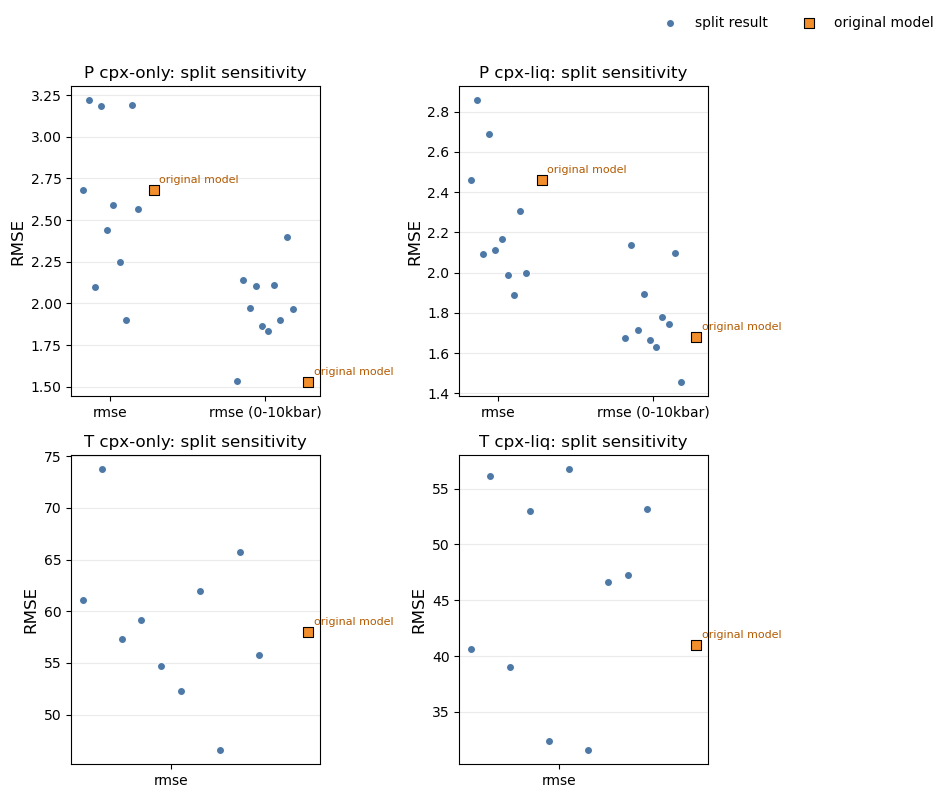

In [9]:
fig